In [2]:
# Pulls everything from Phases 1–5 and assembles it into
# a single publication-quality figure.
#
# Layout (3 rows × 3 cols, with some merged panels):
#
#   [1. Cumulative Portfolio Return + Drawdown        ] [2. VaR vs CVaR Summary Table]
#   [3. Rolling VaR (3 methods) vs Actual Returns     ] [4. Exception Timeline       ]
#   [5. Stress Test Bar Chart                         ] [6. Backtest Results Table   ]

In [8]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
from matplotlib.colors import to_rgba
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams.update({"font.size": 8})

with open("portfolio_data.pkl", "rb") as f:
    data = pickle.load(f)

# ── Phase 1
portfolio_returns = data["portfolio_returns"]
log_returns       = data["log_returns"]
weights           = data["weights"]
tickers           = data["tickers"]

# ── Phase 2
hs_var    = data["hs_var"]
param_var = data["param_var"]
mc_var    = data["mc_var"]

# ── Phase 3
hs_cvar    = data["hs_cvar"]
param_cvar = data["param_cvar"]
mc_cvar    = data["mc_cvar"]

# ── Phase 4
all_bt        = data["backtest_all_results"]
kup_99        = data["kupiec_results_99"]
chris_99      = data["christoffersen_99"]

# ── Phase 5
gfc_cumulative   = data["gfc_cumulative"]
covid_cumulative = data["covid_cumulative"]
rate_cumulative  = data["rate_cumulative"]
stress_worst     = data["stress_worst_days"]

conf_levels = data["conf_levels"]
lookback    = data["lookback"]
returns     = portfolio_returns.values
dates       = portfolio_returns.index

print("All data loaded. Building dashboard ...")

All data loaded. Building dashboard ...


In [9]:
# Cumulative return + drawdown
cum_ret  = portfolio_returns.cumsum()
roll_max = cum_ret.cummax()
drawdown = cum_ret - roll_max   # always ≤ 0

# Rolling VaR series at 99% (already computed in Phase 4)
roll_hs_99    = all_bt[0.99]["roll_hs"]
roll_param_99 = all_bt[0.99]["roll_param"]
roll_mc_99    = all_bt[0.99]["roll_mc"]
exc_hs_99     = all_bt[0.99]["exc_hs"]
valid_dates   = dates[lookback:]

# Backtest summary rows
bt_rows = []
for name, key in [("Hist Sim", "HS"), ("Parametric", "Parametric"), ("Monte Carlo", "MC")]:
    k  = kup_99[key]
    cr = chris_99[key]
    bt_rows.append([
        name,
        k["N"],
        f"{k['p_hat']:.2%}",
        f"{k['p_value']:.3f}",
        "PASS" if not k["reject"]    else "FAIL",
        f"{cr['p_value_cc']:.3f}",
        "PASS" if not cr["reject_cc"] else "FAIL",
    ])
bt_df = pd.DataFrame(bt_rows, columns=[
    "Method", "N exc", "Act Rate", "Kupiec p", "Kupiec",
    "CC p", "CC Test"
])

# VaR/CVaR summary table
vc_rows = []
for name, v, cv in [
    ("Hist Sim",    hs_var,    hs_cvar),
    ("Parametric",  param_var, param_cvar),
    ("Monte Carlo", mc_var,    mc_cvar),
]:
    for c in conf_levels:
        vc_rows.append({
            "Method": name,
            "Conf":   f"{int(c*100)}%",
            "VaR (%)":  f"{v[c]*100:.3f}",
            "CVaR (%)": f"{cv[c]*100:.3f}",
            "VaR ($K)": f"${v[c]*1e6/1e3:,.1f}K",
            "CVaR($K)": f"${cv[c]*1e6/1e3:,.1f}K",
        })
vc_df = pd.DataFrame(vc_rows)

print("Pre-computations done.")

Pre-computations done.


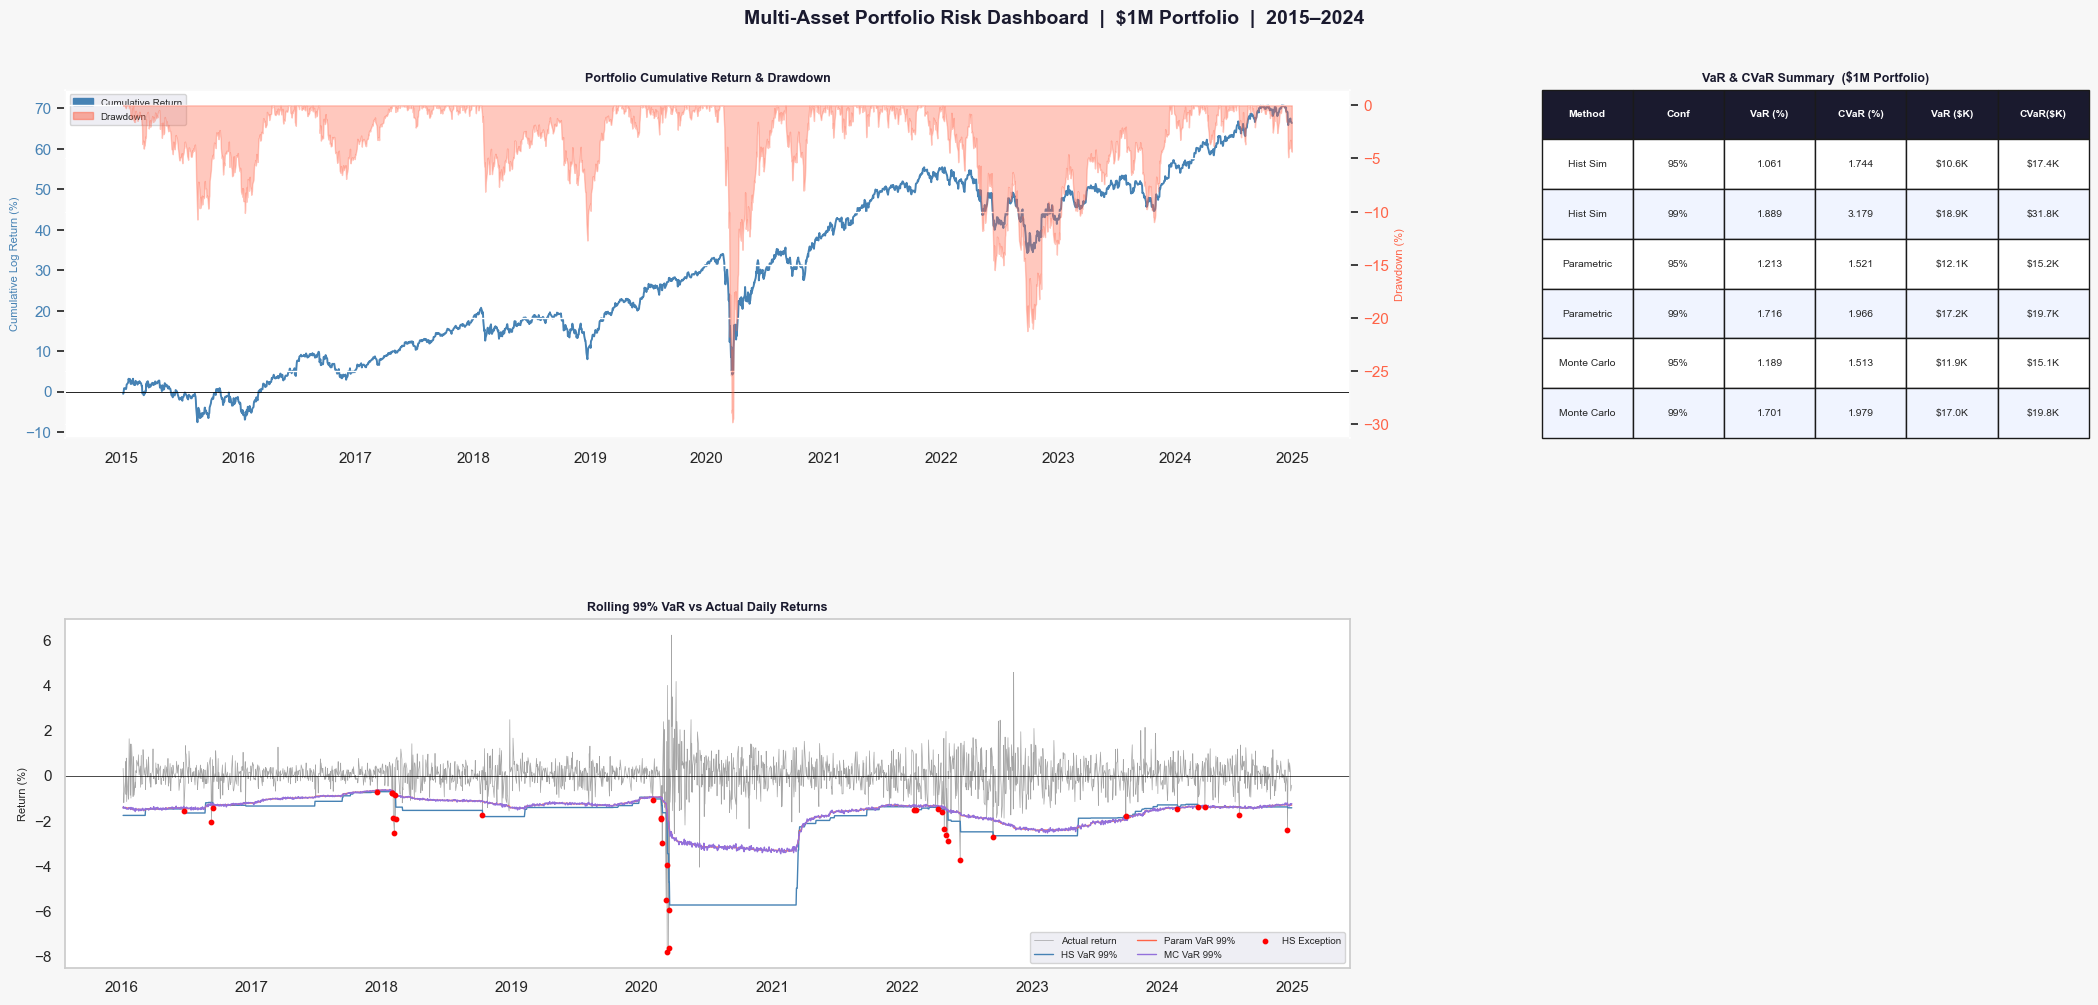

In [10]:
fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor("#f7f7f7")
fig.suptitle(
    "Multi-Asset Portfolio Risk Dashboard  |  $1M Portfolio  |  2015–2024",
    fontsize=14, fontweight="bold", y=0.98, color="#1a1a2e"
)

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.52,
    wspace=0.35,
    left=0.05, right=0.97,
    top=0.93, bottom=0.05,
)

PANEL_COLOR = "#ffffff"
TITLE_COLOR = "#1a1a2e"

def panel_ax(gs_loc, title):
    ax = fig.add_subplot(gs_loc)
    ax.set_facecolor(PANEL_COLOR)
    ax.set_title(title, fontsize=9, fontweight="bold", color=TITLE_COLOR, pad=6)
    for spine in ax.spines.values():
        spine.set_edgecolor("#cccccc")
    return ax


# ── PANEL 1 (top-left span 2 cols): Cumulative Return + Drawdown ──────────
ax1 = panel_ax(gs[0, :2], "Portfolio Cumulative Return & Drawdown")
ax1_twin = ax1.twinx()

ax1.plot(cum_ret.index, cum_ret * 100,
         color="steelblue", linewidth=1.4, label="Cumulative return")
ax1.axhline(0, color="black", linewidth=0.6)
ax1.set_ylabel("Cumulative Log Return (%)", color="steelblue", fontsize=8)
ax1.tick_params(axis="y", labelcolor="steelblue")

ax1_twin.fill_between(drawdown.index, drawdown * 100, 0,
                      color="tomato", alpha=0.35, label="Drawdown")
ax1_twin.set_ylabel("Drawdown (%)", color="tomato", fontsize=8)
ax1_twin.tick_params(axis="y", labelcolor="tomato")

lines1 = [mpatches.Patch(color="steelblue", label="Cumulative Return"),
          mpatches.Patch(color="tomato",    alpha=0.5, label="Drawdown")]
ax1.legend(handles=lines1, fontsize=7, loc="upper left")


# ── PANEL 2 (top-right): VaR / CVaR Summary Table ─────────────────────────
ax2 = panel_ax(gs[0, 2], "VaR & CVaR Summary  ($1M Portfolio)")
ax2.axis("off")

tbl2 = ax2.table(
    cellText=vc_df.values,
    colLabels=vc_df.columns,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(7.5)

# Style header
for j in range(len(vc_df.columns)):
    tbl2[0, j].set_facecolor("#1a1a2e")
    tbl2[0, j].set_text_props(color="white", fontweight="bold")

# Alternate row shading
for i in range(1, len(vc_df) + 1):
    color = "#f0f4ff" if i % 2 == 0 else "#ffffff"
    for j in range(len(vc_df.columns)):
        tbl2[i, j].set_facecolor(color)


# ── PANEL 3 (mid-left span 2 cols): Rolling VaR vs Actual Returns ──────────
ax3 = panel_ax(gs[1, :2], "Rolling 99% VaR vs Actual Daily Returns")

actual_valid = returns[lookback:] * 100
ax3.plot(valid_dates, actual_valid,
         color="grey", linewidth=0.5, alpha=0.7, label="Actual return")
ax3.plot(valid_dates, -roll_hs_99[lookback:]    * 100,
         color="steelblue",   linewidth=1.0, label="HS VaR 99%")
ax3.plot(valid_dates, -roll_param_99[lookback:] * 100,
         color="tomato",      linewidth=1.0, label="Param VaR 99%")
ax3.plot(valid_dates, -roll_mc_99[lookback:]    * 100,
         color="mediumpurple",linewidth=1.0, label="MC VaR 99%")

exc_mask = exc_hs_99[lookback:] == 1
ax3.scatter(valid_dates[exc_mask], actual_valid[exc_mask],
            color="red", s=10, zorder=5, label="HS Exception")

ax3.set_ylabel("Return (%)", fontsize=8)
ax3.legend(fontsize=7, loc="lower right", ncol=3)
ax3.axhline(0, color="black", linewidth=0.5)

In [11]:
ax4 = panel_ax(gs[1, 2], "Exception Timeline — 99% VaR")

exc_configs = [
    ("HS",    all_bt[0.99]["exc_hs"],    "steelblue", 0.75),
    ("Param", all_bt[0.99]["exc_param"], "tomato",    0.50),
    ("MC",    all_bt[0.99]["exc_mc"],    "mediumpurple", 0.25),
]
yticks, ylabels = [], []
for name, exc, color, y_pos in exc_configs:
    exc_  = exc[lookback:]
    exc_d = valid_dates[exc_ == 1]
    ax4.vlines(exc_d, y_pos - 0.12, y_pos + 0.12,
               color=color, linewidth=0.8, alpha=0.8)
    yticks.append(y_pos)
    ylabels.append(f"{name} ({exc_.sum()})")

ax4.set_yticks(yticks)
ax4.set_yticklabels(ylabels, fontsize=7)
ax4.set_ylim(0, 1)
ax4.set_xlabel("Date", fontsize=8)
ax4.xaxis.set_tick_params(labelsize=7)

In [12]:
ax5 = panel_ax(gs[2, :2], "Stress Test: Worst-Day Loss vs VaR / CVaR  ($1M Portfolio)")

scenario_names  = list(stress_worst.keys())
scenario_losses = [v * 1e6 for v in stress_worst.values()]
bar_colors      = ["tomato", "darkorange", "mediumpurple", "dimgray"]

bars = ax5.bar(scenario_names, scenario_losses,
               color=bar_colors, alpha=0.85, width=0.5)
ax5.bar_label(bars,
              labels=[f"${v/1e3:.0f}K" for v in scenario_losses],
              padding=4, fontsize=8)

ax5.axhline(hs_var[0.99]  * 1e6, color="blue", linewidth=1.4, linestyle="--",
            label=f"99% VaR  = ${hs_var[0.99]*1e6/1e3:.0f}K")
ax5.axhline(hs_var[0.95]  * 1e6, color="green", linewidth=1.4, linestyle="--",
            label=f"95% VaR  = ${hs_var[0.95]*1e6/1e3:.0f}K")
ax5.axhline(hs_cvar[0.99] * 1e6, color="red",  linewidth=1.4, linestyle="-",
            label=f"99% CVaR = ${hs_cvar[0.99]*1e6/1e3:.0f}K")

ax5.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax5.set_ylabel("Portfolio Loss ($)", fontsize=8)
ax5.legend(fontsize=7, loc="upper right")
ax5.set_ylim(0, max(scenario_losses) * 1.25)

(0.0, 129687.5)

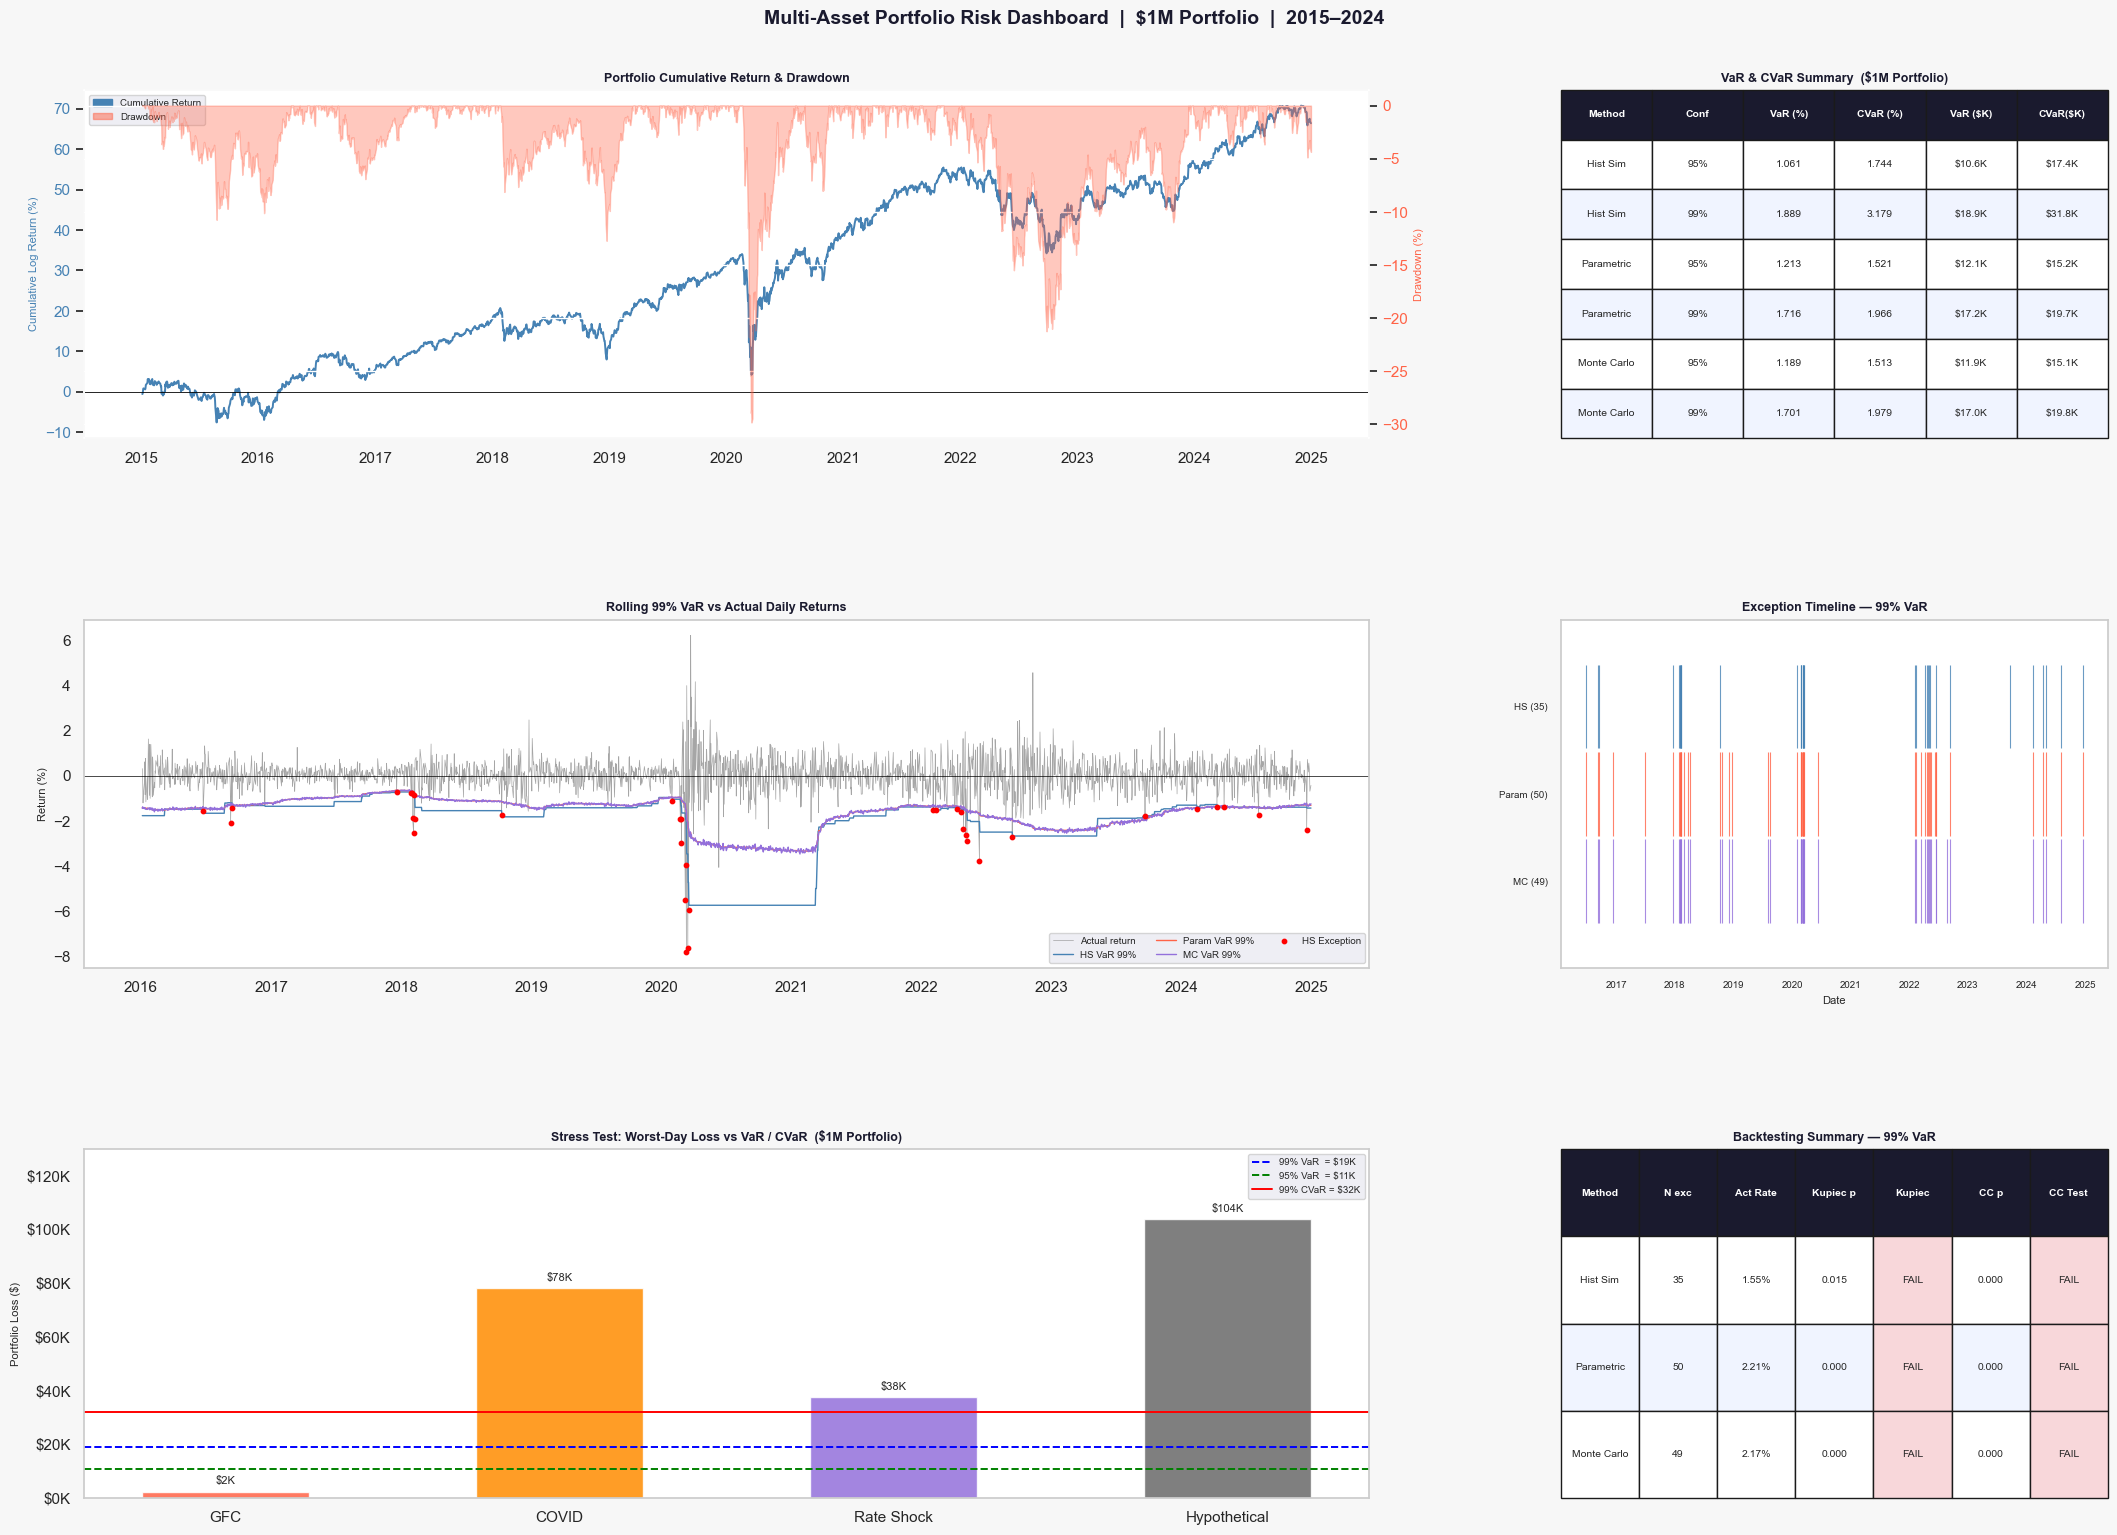

Saved → risk_dashboard.png


In [13]:
ax6 = panel_ax(gs[2, 2], "Backtesting Summary — 99% VaR")
ax6.axis("off")

tbl6 = ax6.table(
    cellText=bt_df.values,
    colLabels=bt_df.columns,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)
tbl6.auto_set_font_size(False)
tbl6.set_fontsize(7.5)

# Header style
for j in range(len(bt_df.columns)):
    tbl6[0, j].set_facecolor("#1a1a2e")
    tbl6[0, j].set_text_props(color="white", fontweight="bold")

# Color PASS/FAIL cells
pass_col = "#d4edda"
fail_col = "#f8d7da"
kupiec_col = bt_df.columns.get_loc("Kupiec")
cc_col     = bt_df.columns.get_loc("CC Test")

for i in range(1, len(bt_df) + 1):
    row_color = "#f0f4ff" if i % 2 == 0 else "#ffffff"
    for j in range(len(bt_df.columns)):
        tbl6[i, j].set_facecolor(row_color)

    kup_val = bt_df.iloc[i - 1]["Kupiec"]
    cc_val  = bt_df.iloc[i - 1]["CC Test"]
    tbl6[i, kupiec_col].set_facecolor(pass_col if kup_val == "PASS" else fail_col)
    tbl6[i, cc_col    ].set_facecolor(pass_col if cc_val  == "PASS" else fail_col)

fig.savefig("risk_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
display(fig)
print("Saved → risk_dashboard.png")